# Análisis Exploratorio de Datos (EDA) - Barcelona Housing Demographics

**Fecha**: 2026-01-06  
**Autor**: Barcelona Housing Demographics Analyzer  
**Health Score**: 100/100 ✅

Este notebook contiene el análisis exploratorio completo de los datos de vivienda y demografía de Barcelona.

## Contenido
1. [Setup y Conexión](#1-setup)
2. [Overview de Datos](#2-overview)
3. [Análisis de Precios](#3-precios)
4. [Análisis Demográfico](#4-demografia)
5. [Análisis de Desempleo](#5-desempleo)
6. [Presión Turística](#6-turismo)
7. [Correlaciones](#7-correlaciones)
8. [Conclusiones](#8-conclusiones)

## 1. Setup y Conexión <a id='1-setup'></a>

In [1]:
# Imports
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# Add project root to path
project_root = Path.cwd().parent if 'notebooks' in str(Path.cwd()) else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.database import DatabaseManager

print("✅ Imports completados")
print(f"📁 Project root: {project_root}")

✅ Imports completados
📁 Project root: /Users/adrianiraeguialvear/Projects/barcelona-housing-demographics-analyzer


In [2]:
# Conectar a la base de datos
db_manager = DatabaseManager()
conn = db_manager.get_connection()

print("✅ Conexión establecida")

# Verificar health score
cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM sqlite_master WHERE type='table'")
num_tables = cursor.fetchone()[0]

cursor.execute("""
    SELECT SUM(total_rows) FROM (
        SELECT COUNT(*) as total_rows FROM fact_precios
        UNION ALL SELECT COUNT(*) FROM fact_demografia
        UNION ALL SELECT COUNT(*) FROM fact_desempleo
    )
""")
total_rows = cursor.fetchone()[0]

print(f"📊 Tablas: {num_tables}")
print(f"📊 Registros totales (muestra): {total_rows:,}")

✅ Conexión establecida
📊 Tablas: 35
📊 Registros totales (muestra): 8,913


## 2. Overview de Datos <a id='2-overview'></a>

In [3]:
# Obtener lista de barrios
df_barrios = pd.read_sql("""
    SELECT barrio_id, barrio_nombre, distrito_nombre
    FROM dim_barrios
    ORDER BY distrito_nombre, barrio_nombre
""", conn)

print(f"📍 Total de barrios: {len(df_barrios)}")
print(f"📍 Total de distritos: {df_barrios['distrito_nombre'].nunique()}")
print("\nPrimeros barrios:")
df_barrios.head(10)

📍 Total de barrios: 73
📍 Total de distritos: 10

Primeros barrios:


,barrio_id,barrio_nombre,distrito_nombre
0,4,"Sant Pere, Santa Caterina i la Ribera",Ciutat Vella
1,2,el Barri Gòtic,Ciutat Vella
2,1,el Raval,Ciutat Vella
3,3,la Barceloneta,Ciutat Vella
4,10,Sant Antoni,Eixample
5,5,el Fort Pienc,Eixample
6,8,l'Antiga Esquerra de l'Eixample,Eixample
7,7,la Dreta de l'Eixample,Eixample
8,9,la Nova Esquerra de l'Eixample,Eixample
9,6,la Sagrada Família,Eixample


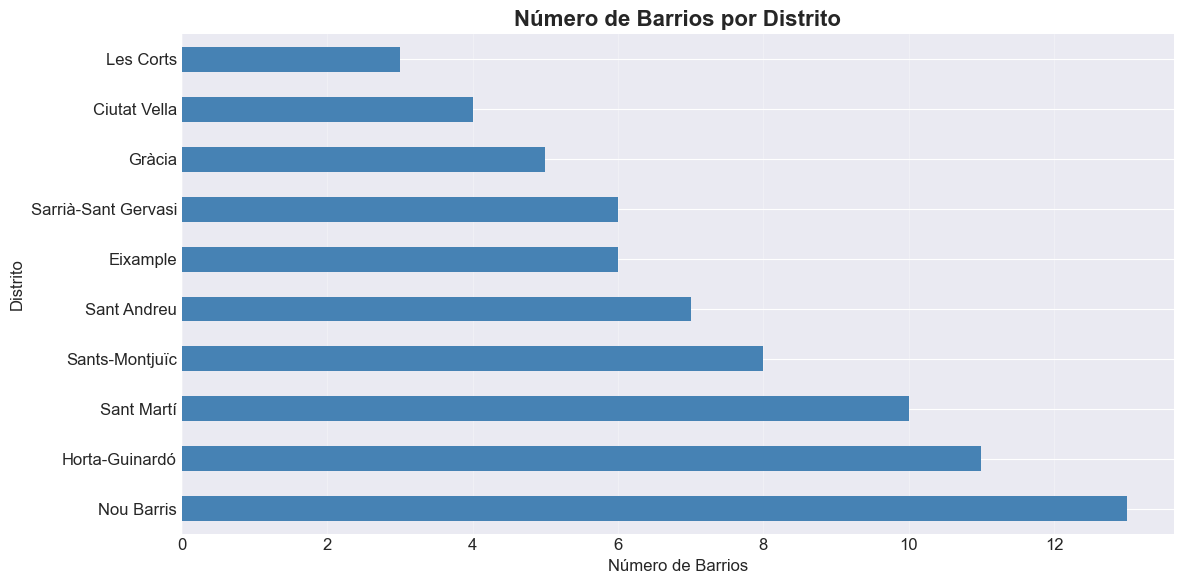


Barrios por distrito:
distrito_nombre
Nou Barris             13
Horta-Guinardó         11
Sant Martí             10
Sants-Montjuïc          8
Sant Andreu             7
Eixample                6
Sarrià-Sant Gervasi     6
Gràcia                  5
Ciutat Vella            4
Les Corts               3
dtype: int64


In [4]:
# Distribución de barrios por distrito
barrios_por_distrito = df_barrios.groupby('distrito_nombre').size().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
barrios_por_distrito.plot(kind='barh', color='steelblue')
plt.title('Número de Barrios por Distrito', fontsize=16, fontweight='bold')
plt.xlabel('Número de Barrios')
plt.ylabel('Distrito')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nBarrios por distrito:")
print(barrios_por_distrito)

## 3. Análisis de Precios <a id='3-precios'></a>

In [5]:
# Cargar datos de precios
df_precios = pd.read_sql("""
    SELECT 
        p.barrio_id,
        b.barrio_nombre,
        b.distrito_nombre,
        p.anio,
        p.precio_m2_venta,
        p.precio_mes_alquiler
    FROM fact_precios p
    JOIN dim_barrios b ON p.barrio_id = b.barrio_id
    WHERE p.precio_m2_venta IS NOT NULL
    ORDER BY p.anio, b.barrio_nombre
""", conn)

print(f"📊 Registros de precios: {len(df_precios):,}")
print(f"📅 Años: {df_precios['anio'].min()} - {df_precios['anio'].max()}")
print(f"💰 Precio medio: {df_precios['precio_m2_venta'].mean():.2f}€/m²")

df_precios.head()

📊 Registros de precios: 5,492
📅 Años: 2012 - 2025
💰 Precio medio: 3191.64€/m²


,barrio_id,barrio_nombre,distrito_nombre,anio,precio_m2_venta,precio_mes_alquiler
0,34,Can Baró,Horta-Guinardó,2012,2869.166748,None
1,34,Can Baró,Horta-Guinardó,2012,1875.800049,None
2,34,Can Baró,Horta-Guinardó,2012,2869.166748,None
3,49,Canyelles,Nou Barris,2012,1484.062500,None
4,49,Canyelles,Nou Barris,2012,1484.062500,None


📊 Estadísticas de Precio de Venta (€/m²)

count    5492.000000
mean     3191.641847
std      1234.426519
min       342.609985
25%      2251.891785
50%      3044.855835
75%      4010.166016
max      8815.320312
Name: precio_m2_venta, dtype: float64


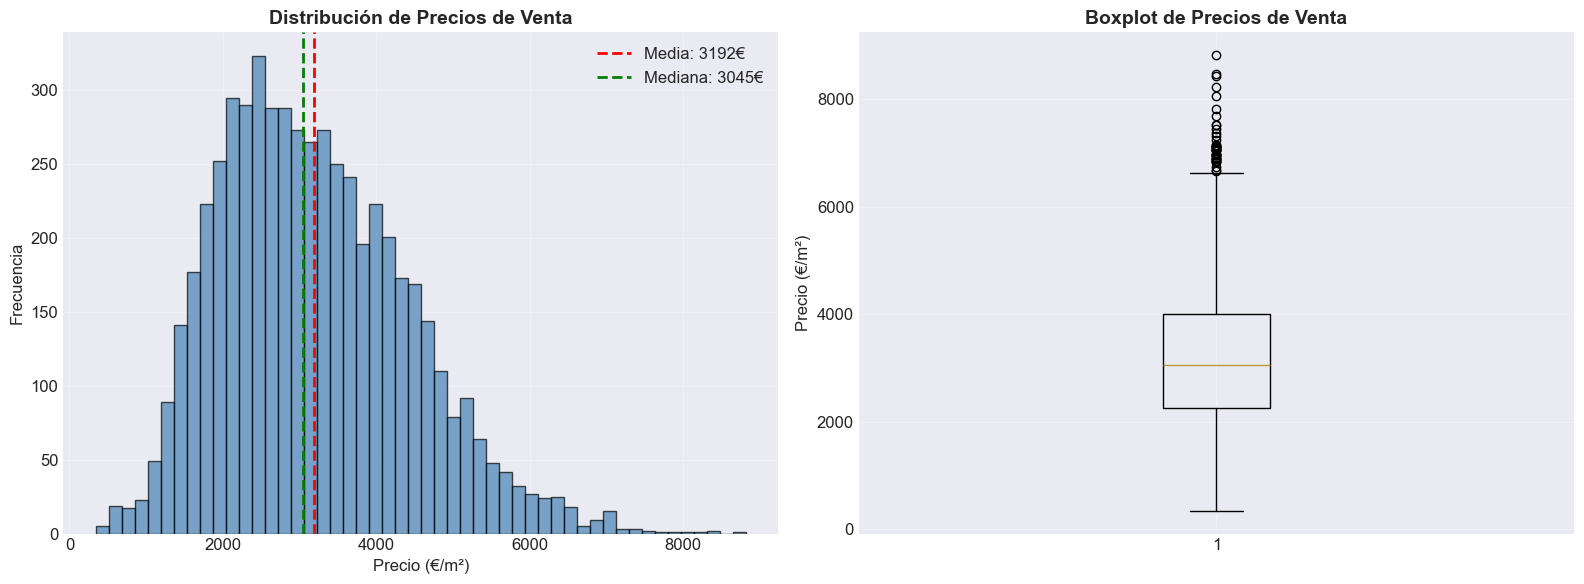

In [6]:
# Estadísticas descriptivas de precios
print("📊 Estadísticas de Precio de Venta (€/m²)\n")
print(df_precios['precio_m2_venta'].describe())

# Visualización de distribución
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma
axes[0].hist(df_precios['precio_m2_venta'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df_precios['precio_m2_venta'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df_precios["precio_m2_venta"].mean():.0f}€')
axes[0].axvline(df_precios['precio_m2_venta'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {df_precios["precio_m2_venta"].median():.0f}€')
axes[0].set_title('Distribución de Precios de Venta', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Precio (€/m²)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot
axes[1].boxplot(df_precios['precio_m2_venta'], vert=True)
axes[1].set_title('Boxplot de Precios de Venta', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Precio (€/m²)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

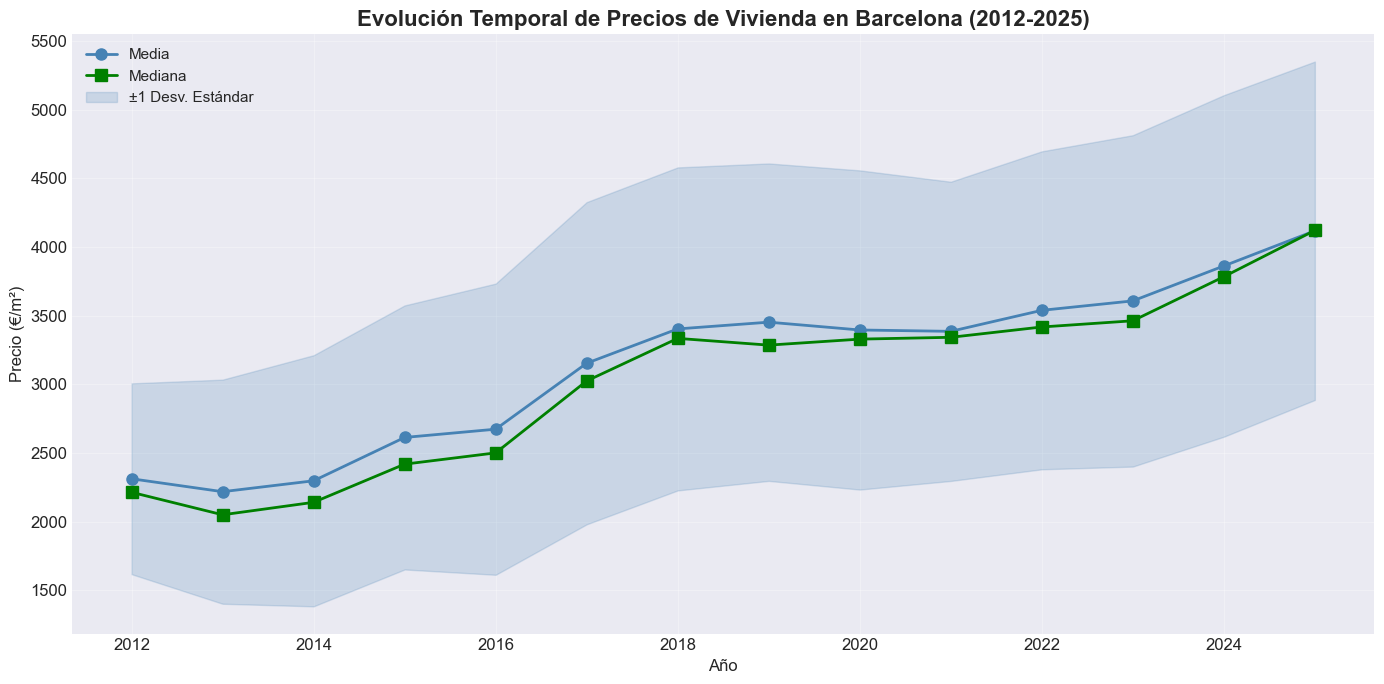


📈 Variación 2012-2025: +78.0%
💰 Precio 2012: 2313.20€/m²
💰 Precio 2025: 4118.36€/m²


In [7]:
# Evolución temporal de precios
precios_por_anio = df_precios.groupby('anio')['precio_m2_venta'].agg(['mean', 'median', 'std']).reset_index()

plt.figure(figsize=(14, 7))
plt.plot(precios_por_anio['anio'], precios_por_anio['mean'], marker='o', linewidth=2, markersize=8, label='Media', color='steelblue')
plt.plot(precios_por_anio['anio'], precios_por_anio['median'], marker='s', linewidth=2, markersize=8, label='Mediana', color='green')
plt.fill_between(precios_por_anio['anio'], 
                 precios_por_anio['mean'] - precios_por_anio['std'],
                 precios_por_anio['mean'] + precios_por_anio['std'],
                 alpha=0.2, color='steelblue', label='±1 Desv. Estándar')

plt.title('Evolución Temporal de Precios de Vivienda en Barcelona (2012-2025)', fontsize=16, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Precio (€/m²)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calcular variación
precio_inicial = precios_por_anio.iloc[0]['mean']
precio_final = precios_por_anio.iloc[-1]['mean']
variacion_pct = ((precio_final - precio_inicial) / precio_inicial) * 100

print(f"\n📈 Variación 2012-2025: {variacion_pct:+.1f}%")
print(f"💰 Precio 2012: {precio_inicial:.2f}€/m²")
print(f"💰 Precio 2025: {precio_final:.2f}€/m²")

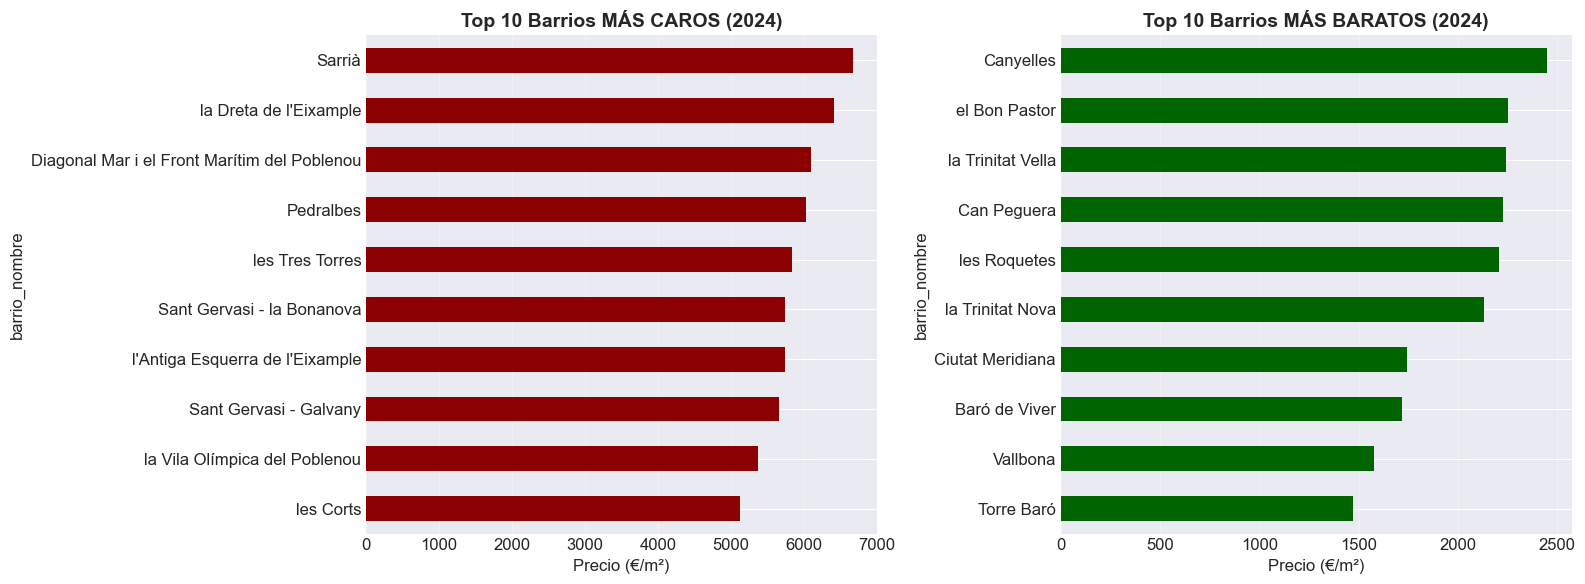


🏆 Top 5 MÁS CAROS:
barrio_nombre
les Tres Torres                                 5841.200358
Pedralbes                                       6023.335205
Diagonal Mar i el Front Marítim del Poblenou    6100.162109
la Dreta de l'Eixample                          6411.979329
Sarrià                                          6668.619466
Name: precio_m2_venta, dtype: float64

💰 Top 5 MÁS BARATOS:
barrio_nombre
Torre Baró          1473.696289
Vallbona            1578.000000
Baró de Viver       1717.656779
Ciutat Meridiana    1745.688883
la Trinitat Nova    2133.081502
Name: precio_m2_venta, dtype: float64


In [8]:
# Top 10 barrios más caros y más baratos (2024)
precios_2024 = df_precios[df_precios['anio'] == 2024].groupby('barrio_nombre')['precio_m2_venta'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Más caros
precios_2024.tail(10).plot(kind='barh', ax=axes[0], color='darkred')
axes[0].set_title('Top 10 Barrios MÁS CAROS (2024)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Precio (€/m²)')
axes[0].grid(axis='x', alpha=0.3)

# Más baratos
precios_2024.head(10).plot(kind='barh', ax=axes[1], color='darkgreen')
axes[1].set_title('Top 10 Barrios MÁS BARATOS (2024)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Precio (€/m²)')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🏆 Top 5 MÁS CAROS:")
print(precios_2024.tail(5))
print("\n💰 Top 5 MÁS BARATOS:")
print(precios_2024.head(5))

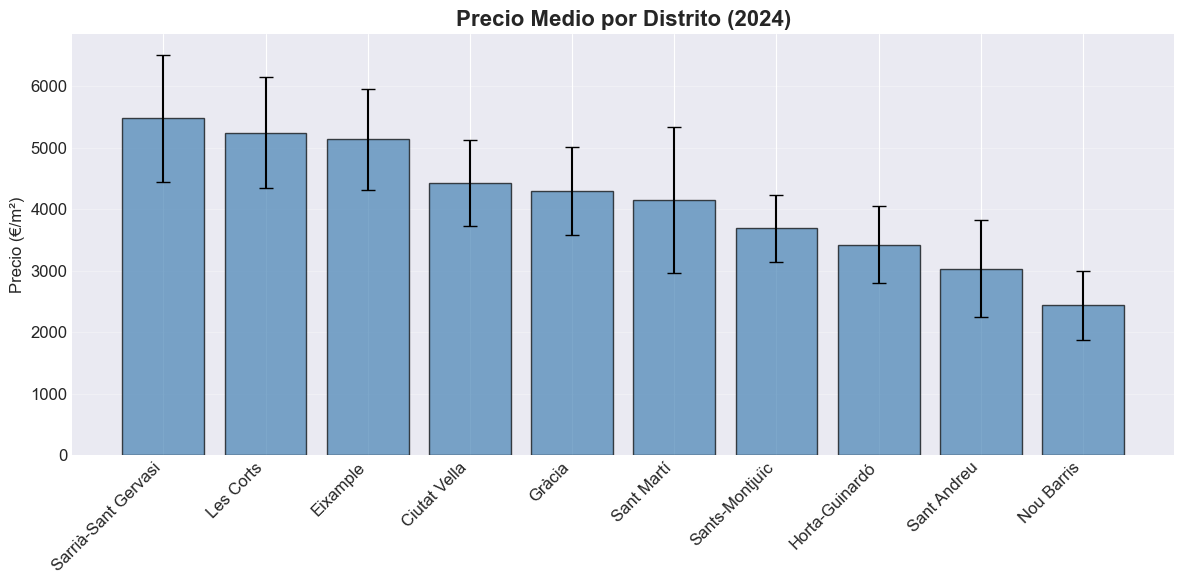


📊 Precios por Distrito (2024):
                            mean       median          std
distrito_nombre                                           
Sarrià-Sant Gervasi  5479.730413  5286.073730  1037.742850
Les Corts            5243.121352  5040.287109   901.621057
Eixample             5135.129937  4884.719971   821.523900
Ciutat Vella         4427.621480  4561.925049   701.138978
Gràcia               4293.081486  4340.316650   718.127017
Sant Martí           4150.152104  4118.777832  1182.793513
Sants-Montjuïc       3691.163386  3757.396851   547.140933
Horta-Guinardó       3421.434884  3446.932861   624.907100
Sant Andreu          3033.537044  3275.564697   791.805255
Nou Barris           2434.863797  2432.084961   565.064180


In [9]:
# Precios por distrito (2024)
precios_distrito_2024 = df_precios[df_precios['anio'] == 2024].groupby('distrito_nombre')['precio_m2_venta'].agg(['mean', 'median', 'std']).sort_values('mean', ascending=False)

plt.figure(figsize=(12, 6))
x = range(len(precios_distrito_2024))
plt.bar(x, precios_distrito_2024['mean'], yerr=precios_distrito_2024['std'], 
        capsize=5, color='steelblue', alpha=0.7, edgecolor='black')
plt.xticks(x, precios_distrito_2024.index, rotation=45, ha='right')
plt.title('Precio Medio por Distrito (2024)', fontsize=16, fontweight='bold')
plt.ylabel('Precio (€/m²)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Precios por Distrito (2024):")
print(precios_distrito_2024)

## 4. Análisis Demográfico <a id='4-demografia'></a>

In [10]:
# Cargar datos demográficos
df_demografia = pd.read_sql("""
    SELECT 
        d.barrio_id,
        b.barrio_nombre,
        b.distrito_nombre,
        d.poblacion_total,
        d.densidad_hab_km2
    FROM fact_demografia d
    JOIN dim_barrios b ON d.barrio_id = b.barrio_id
    WHERE d.poblacion_total IS NOT NULL
""", conn)

print(f"📊 Registros demográficos: {len(df_demografia):,}")
print(f"👥 Población total Barcelona: {df_demografia['poblacion_total'].sum():,} habitantes")
print(f"👥 Población media por barrio: {df_demografia['poblacion_total'].mean():.0f} habitantes")

df_demografia.head()

📊 Registros demográficos: 803
👥 Población total Barcelona: 17,908,375 habitantes
👥 Población media por barrio: 22302 habitantes


,barrio_id,barrio_nombre,distrito_nombre,poblacion_total,densidad_hab_km2
0,4,"Sant Pere, Santa Caterina i la Ribera",Ciutat Vella,22468,26435.304804
1,4,"Sant Pere, Santa Caterina i la Ribera",Ciutat Vella,22380,26331.766134
2,4,"Sant Pere, Santa Caterina i la Ribera",Ciutat Vella,22923,26970.646787
3,4,"Sant Pere, Santa Caterina i la Ribera",Ciutat Vella,22605,26596.495687
4,4,"Sant Pere, Santa Caterina i la Ribera",Ciutat Vella,23170,27261.261007


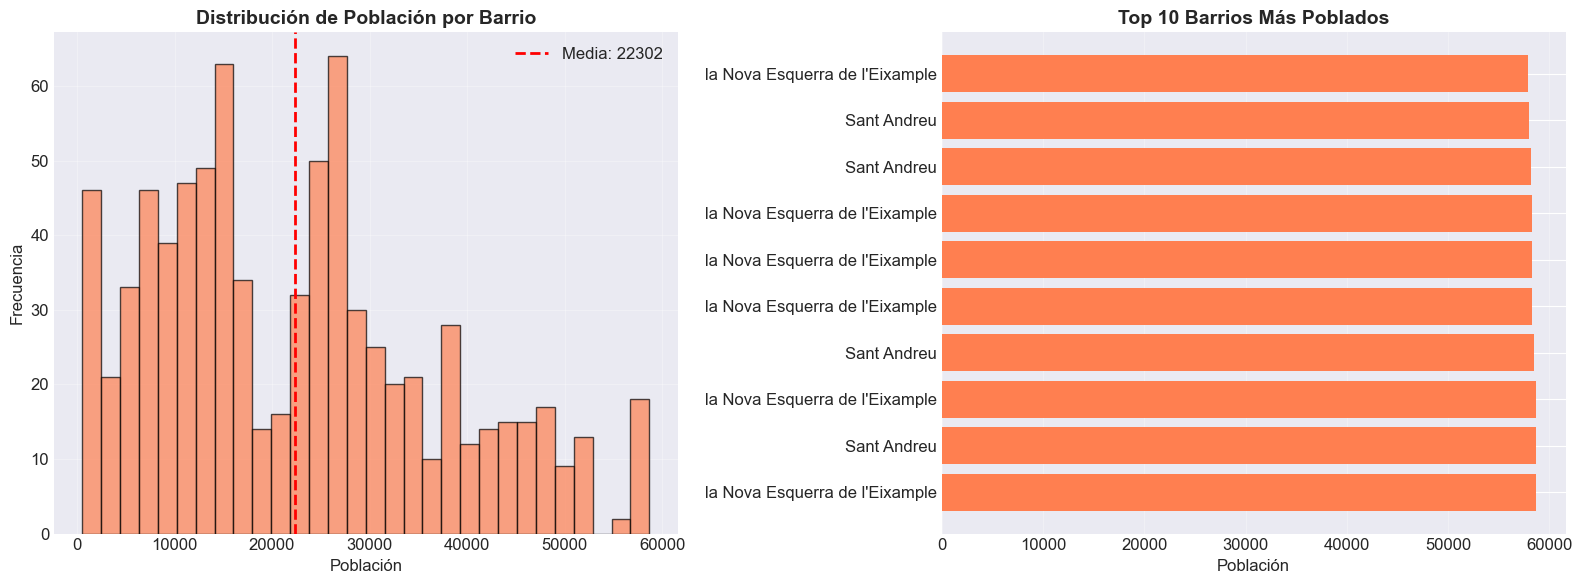

In [11]:
# Distribución de población
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma
axes[0].hist(df_demografia['poblacion_total'], bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[0].axvline(df_demografia['poblacion_total'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df_demografia["poblacion_total"].mean():.0f}')
axes[0].set_title('Distribución de Población por Barrio', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Población')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Top 10 barrios más poblados
top_poblacion = df_demografia.nlargest(10, 'poblacion_total')
axes[1].barh(range(len(top_poblacion)), top_poblacion['poblacion_total'], color='coral')
axes[1].set_yticks(range(len(top_poblacion)))
axes[1].set_yticklabels(top_poblacion['barrio_nombre'])
axes[1].set_title('Top 10 Barrios Más Poblados', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Población')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Análisis de Desempleo <a id='5-desempleo'></a>

In [12]:
# Cargar datos de desempleo
df_desempleo = pd.read_sql("""
    SELECT 
        de.barrio_id,
        b.barrio_nombre,
        b.distrito_nombre,
        de.anio,
        de.mes,
        de.num_desempleados,
        de.tasa_desempleo_estimada
    FROM fact_desempleo de
    JOIN dim_barrios b ON de.barrio_id = b.barrio_id
    WHERE de.tasa_desempleo_estimada IS NOT NULL
    ORDER BY de.anio, de.mes
""", conn)

print(f"📊 Registros de desempleo: {len(df_desempleo):,}")
print(f"📅 Período: {df_desempleo['anio'].min()}-{df_desempleo['anio'].max()}")
print(f"📉 Tasa media: {df_desempleo['tasa_desempleo_estimada'].mean():.2f}%")

df_desempleo.head()

📊 Registros de desempleo: 1,752
📅 Período: 2023-2024
📉 Tasa media: 6.27%


,barrio_id,barrio_nombre,distrito_nombre,anio,mes,num_desempleados,tasa_desempleo_estimada
0,4,"Sant Pere, Santa Caterina i la Ribera",Ciutat Vella,2023,1,1017,6.61
1,2,el Barri Gòtic,Ciutat Vella,2023,1,1238,6.39
2,1,el Raval,Ciutat Vella,2023,1,1852,5.81
3,3,la Barceloneta,Ciutat Vella,2023,1,657,6.49
4,10,Sant Antoni,Eixample,2023,1,1687,6.47


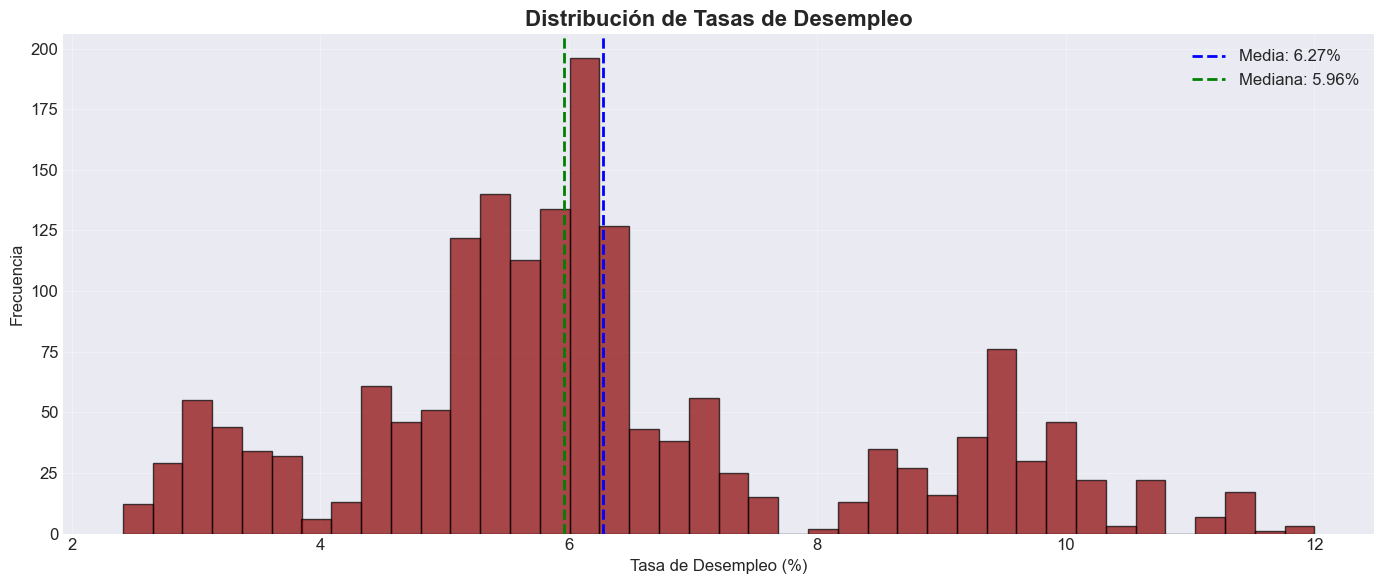

In [13]:
# Distribución de tasas de desempleo
plt.figure(figsize=(14, 6))
plt.hist(df_desempleo['tasa_desempleo_estimada'], bins=40, color='darkred', edgecolor='black', alpha=0.7)
plt.axvline(df_desempleo['tasa_desempleo_estimada'].mean(), color='blue', linestyle='--', linewidth=2, label=f'Media: {df_desempleo["tasa_desempleo_estimada"].mean():.2f}%')
plt.axvline(df_desempleo['tasa_desempleo_estimada'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {df_desempleo["tasa_desempleo_estimada"].median():.2f}%')
plt.title('Distribución de Tasas de Desempleo', fontsize=16, fontweight='bold')
plt.xlabel('Tasa de Desempleo (%)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

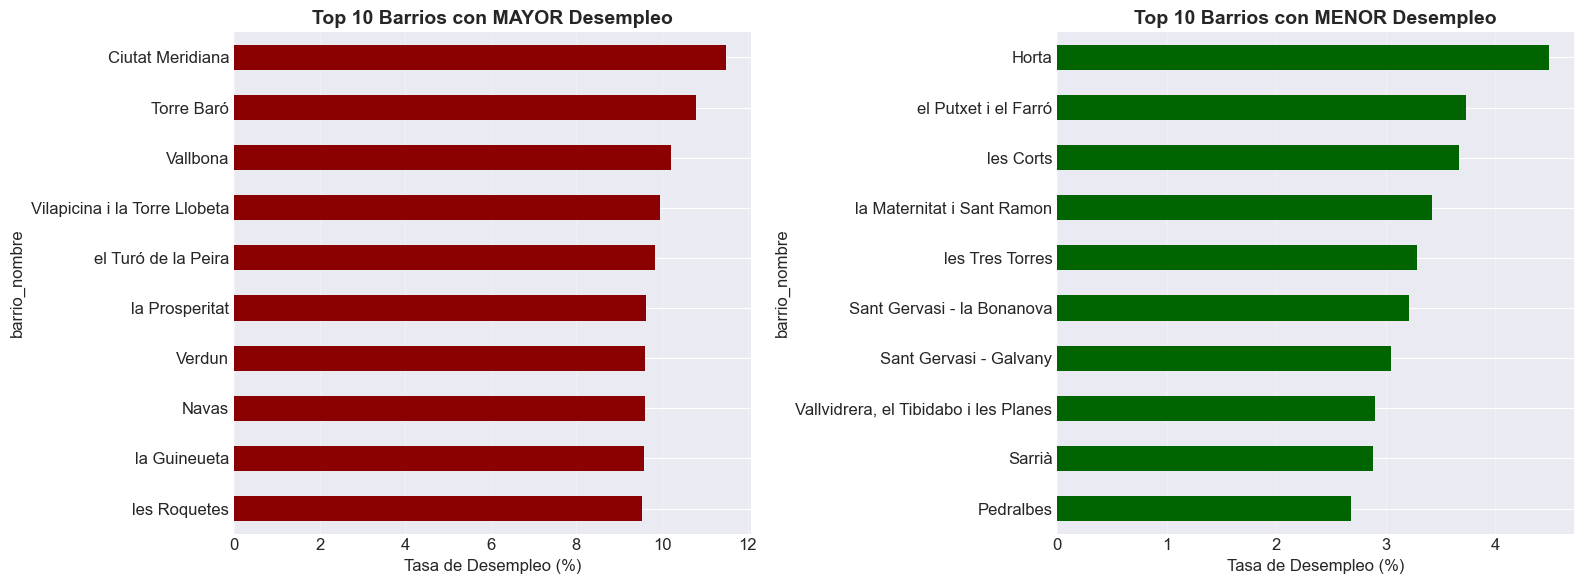


📊 Top 5 MAYOR desempleo:
barrio_nombre
el Turó de la Peira               9.826667
Vilapicina i la Torre Llobeta     9.945833
Vallbona                         10.208750
Torre Baró                       10.793333
Ciutat Meridiana                 11.493750
Name: tasa_desempleo_estimada, dtype: float64

📊 Top 5 MENOR desempleo:
barrio_nombre
Pedralbes                                2.680417
Sarrià                                   2.887500
Vallvidrera, el Tibidabo i les Planes    2.899167
Sant Gervasi - Galvany                   3.054167
Sant Gervasi - la Bonanova               3.217083
Name: tasa_desempleo_estimada, dtype: float64


In [14]:
# Barrios con mayor y menor desempleo (promedio 2023-2024)
desempleo_por_barrio = df_desempleo.groupby('barrio_nombre')['tasa_desempleo_estimada'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mayor desempleo
desempleo_por_barrio.tail(10).plot(kind='barh', ax=axes[0], color='darkred')
axes[0].set_title('Top 10 Barrios con MAYOR Desempleo', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tasa de Desempleo (%)')
axes[0].grid(axis='x', alpha=0.3)

# Menor desempleo
desempleo_por_barrio.head(10).plot(kind='barh', ax=axes[1], color='darkgreen')
axes[1].set_title('Top 10 Barrios con MENOR Desempleo', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tasa de Desempleo (%)')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Top 5 MAYOR desempleo:")
print(desempleo_por_barrio.tail(5))
print("\n📊 Top 5 MENOR desempleo:")
print(desempleo_por_barrio.head(5))

## 6. Presión Turística <a id='6-turismo'></a>

In [15]:
# Cargar datos de presión turística
df_turismo = pd.read_sql("""
    SELECT 
        pt.barrio_id,
        b.barrio_nombre,
        b.distrito_nombre,
        pt.anio,
        pt.num_listings_airbnb,
        pt.precio_noche_promedio
    FROM fact_presion_turistica pt
    JOIN dim_barrios b ON pt.barrio_id = b.barrio_id
    WHERE pt.num_listings_airbnb IS NOT NULL
    ORDER BY pt.anio
""", conn)

print(f"📊 Registros de turismo: {len(df_turismo):,}")
print(f"📅 Período: {df_turismo['anio'].min()}-{df_turismo['anio'].max()}")
print(f"🏨 Listings promedio: {df_turismo['num_listings_airbnb'].mean():.1f}")

df_turismo.head()

📊 Registros de turismo: 2,093
📅 Período: 2011-2025
🏨 Listings promedio: 6.9


,barrio_id,barrio_nombre,distrito_nombre,anio,num_listings_airbnb,precio_noche_promedio
0,28,Vallcarca i els Penitents,Gràcia,2011,1,315.0
1,4,"Sant Pere, Santa Caterina i la Ribera",Ciutat Vella,2012,1,250.0
2,19,les Corts,Les Corts,2012,1,140.0
3,2,el Barri Gòtic,Ciutat Vella,2013,1,70.0
4,67,la Vila Olímpica del Poblenou,Sant Martí,2013,1,380.0


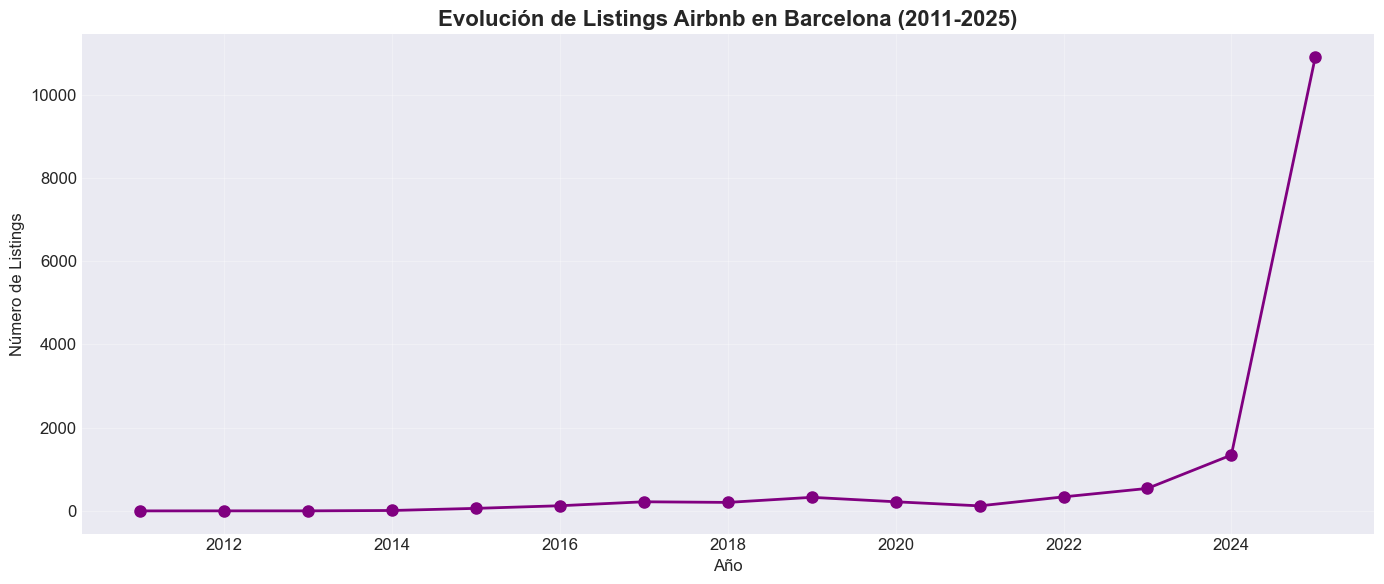


📈 Crecimiento total: +1090100.0%


In [16]:
# Evolución de listings Airbnb
listings_por_anio = df_turismo.groupby('anio')['num_listings_airbnb'].sum()

plt.figure(figsize=(14, 6))
plt.plot(listings_por_anio.index, listings_por_anio.values, marker='o', linewidth=2, markersize=8, color='purple')
plt.title('Evolución de Listings Airbnb en Barcelona (2011-2025)', fontsize=16, fontweight='bold')
plt.xlabel('Año')
plt.ylabel('Número de Listings')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calcular crecimiento
if len(listings_por_anio) > 1:
    crecimiento = ((listings_por_anio.iloc[-1] - listings_por_anio.iloc[0]) / listings_por_anio.iloc[0]) * 100
    print(f"\n📈 Crecimiento total: {crecimiento:+.1f}%")

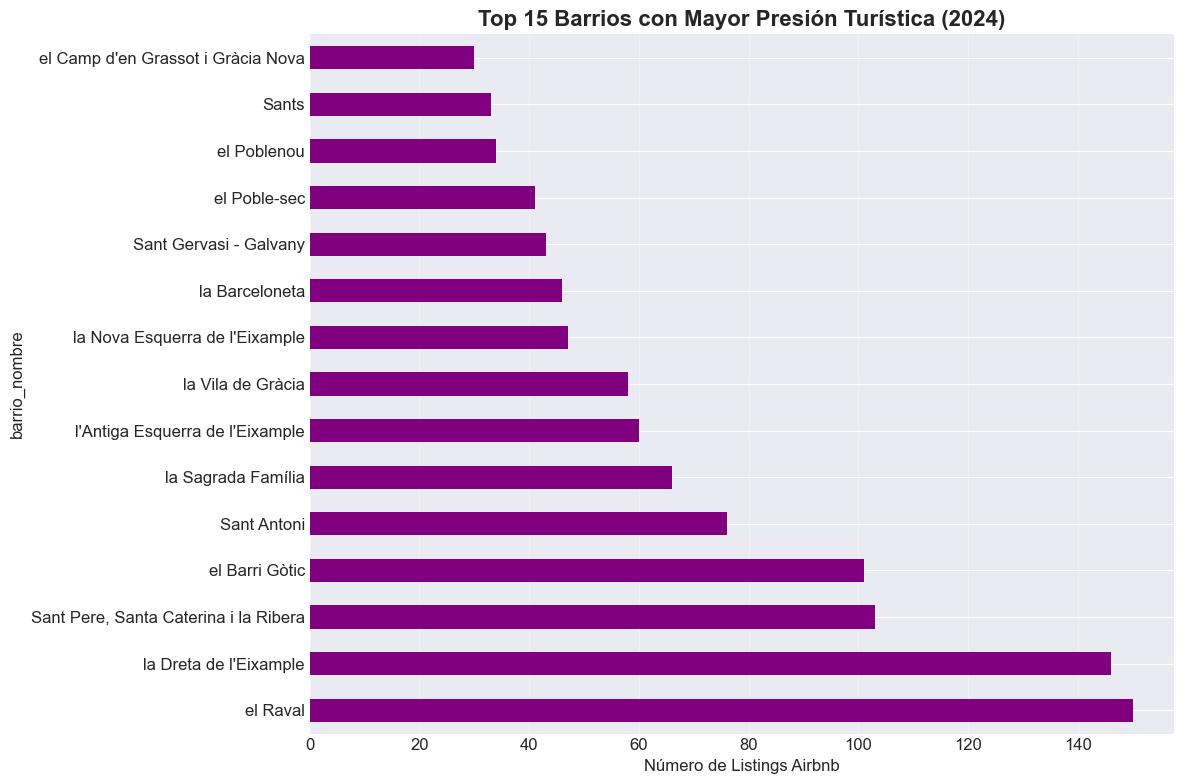


🏨 Top 10 barrios con más listings:
barrio_nombre
el Raval                                 150
la Dreta de l'Eixample                   146
Sant Pere, Santa Caterina i la Ribera    103
el Barri Gòtic                           101
Sant Antoni                               76
la Sagrada Família                        66
l'Antiga Esquerra de l'Eixample           60
la Vila de Gràcia                         58
la Nova Esquerra de l'Eixample            47
la Barceloneta                            46
Name: num_listings_airbnb, dtype: int64


In [17]:
# Barrios con mayor presión turística (2024)
turismo_2024 = df_turismo[df_turismo['anio'] == 2024].groupby('barrio_nombre')['num_listings_airbnb'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
turismo_2024.head(15).plot(kind='barh', color='purple')
plt.title('Top 15 Barrios con Mayor Presión Turística (2024)', fontsize=16, fontweight='bold')
plt.xlabel('Número de Listings Airbnb')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n🏨 Top 10 barrios con más listings:")
print(turismo_2024.head(10))

## 7. Correlaciones <a id='7-correlaciones'></a>

In [18]:
# Crear dataset consolidado para correlaciones (2024)
df_correlaciones = pd.read_sql("""
    SELECT 
        p.barrio_id,
        b.barrio_nombre,
        AVG(p.precio_m2_venta) as precio_venta,
        AVG(d.poblacion_total) as poblacion,
        AVG(de.tasa_desempleo_estimada) as tasa_desempleo,
        SUM(pt.num_listings_airbnb) as airbnb_listings
    FROM fact_precios p
    JOIN dim_barrios b ON p.barrio_id = b.barrio_id
    LEFT JOIN fact_demografia d ON p.barrio_id = d.barrio_id
    LEFT JOIN fact_desempleo de ON p.barrio_id = de.barrio_id AND de.anio = 2024
    LEFT JOIN fact_presion_turistica pt ON p.barrio_id = pt.barrio_id AND pt.anio = 2024
    WHERE p.anio = 2024
    GROUP BY p.barrio_id, b.barrio_nombre
""", conn)

print(f"📊 Barrios para análisis de correlaciones: {len(df_correlaciones)}")
df_correlaciones.head()

📊 Barrios para análisis de correlaciones: 73


,barrio_id,barrio_nombre,precio_venta,poblacion,tasa_desempleo,airbnb_listings
0,1,el Raval,3477.743083,46883.727273,5.430000,138600.0
1,2,el Barri Gòtic,4727.915283,20736.090909,6.071667,93324.0
2,3,la Barceloneta,5049.770101,14719.818182,6.124167,42504.0
3,4,"Sant Pere, Santa Caterina i la Ribera",4455.057454,22444.636364,6.145833,95172.0
4,5,el Fort Pienc,4501.233643,32999.181818,5.512500,20328.0


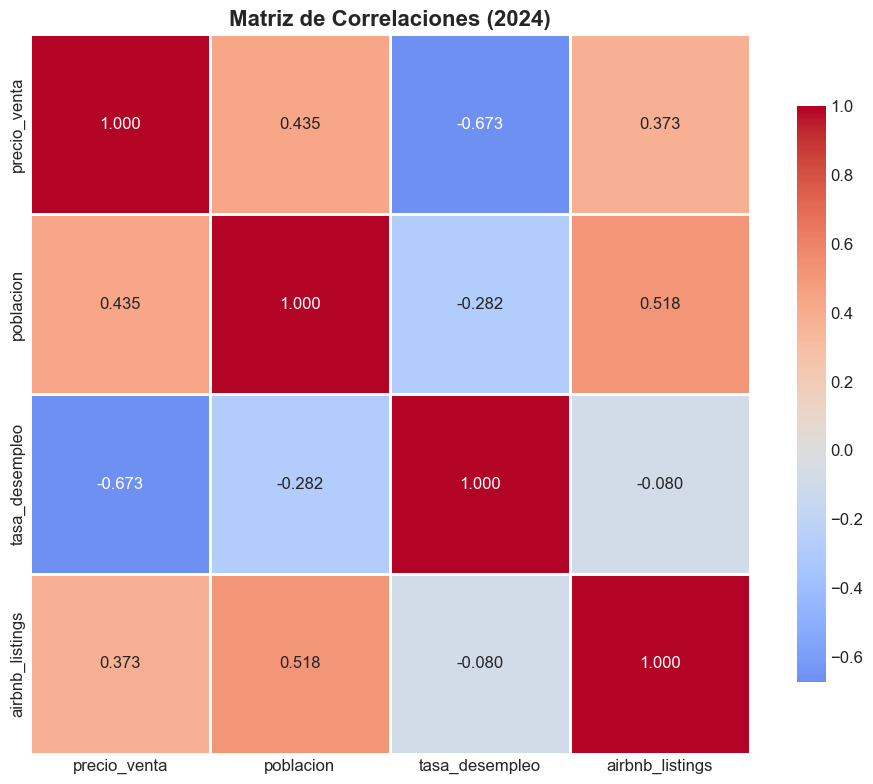


📊 Matriz de Correlaciones:
                 precio_venta  poblacion  tasa_desempleo  airbnb_listings
precio_venta         1.000000   0.435435       -0.672838         0.372879
poblacion            0.435435   1.000000       -0.282149         0.517770
tasa_desempleo      -0.672838  -0.282149        1.000000        -0.079599
airbnb_listings      0.372879   0.517770       -0.079599         1.000000


In [19]:
# Matriz de correlación
numeric_cols = ['precio_venta', 'poblacion', 'tasa_desempleo', 'airbnb_listings']
corr_matrix = df_correlaciones[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlaciones (2024)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Matriz de Correlaciones:")
print(corr_matrix)

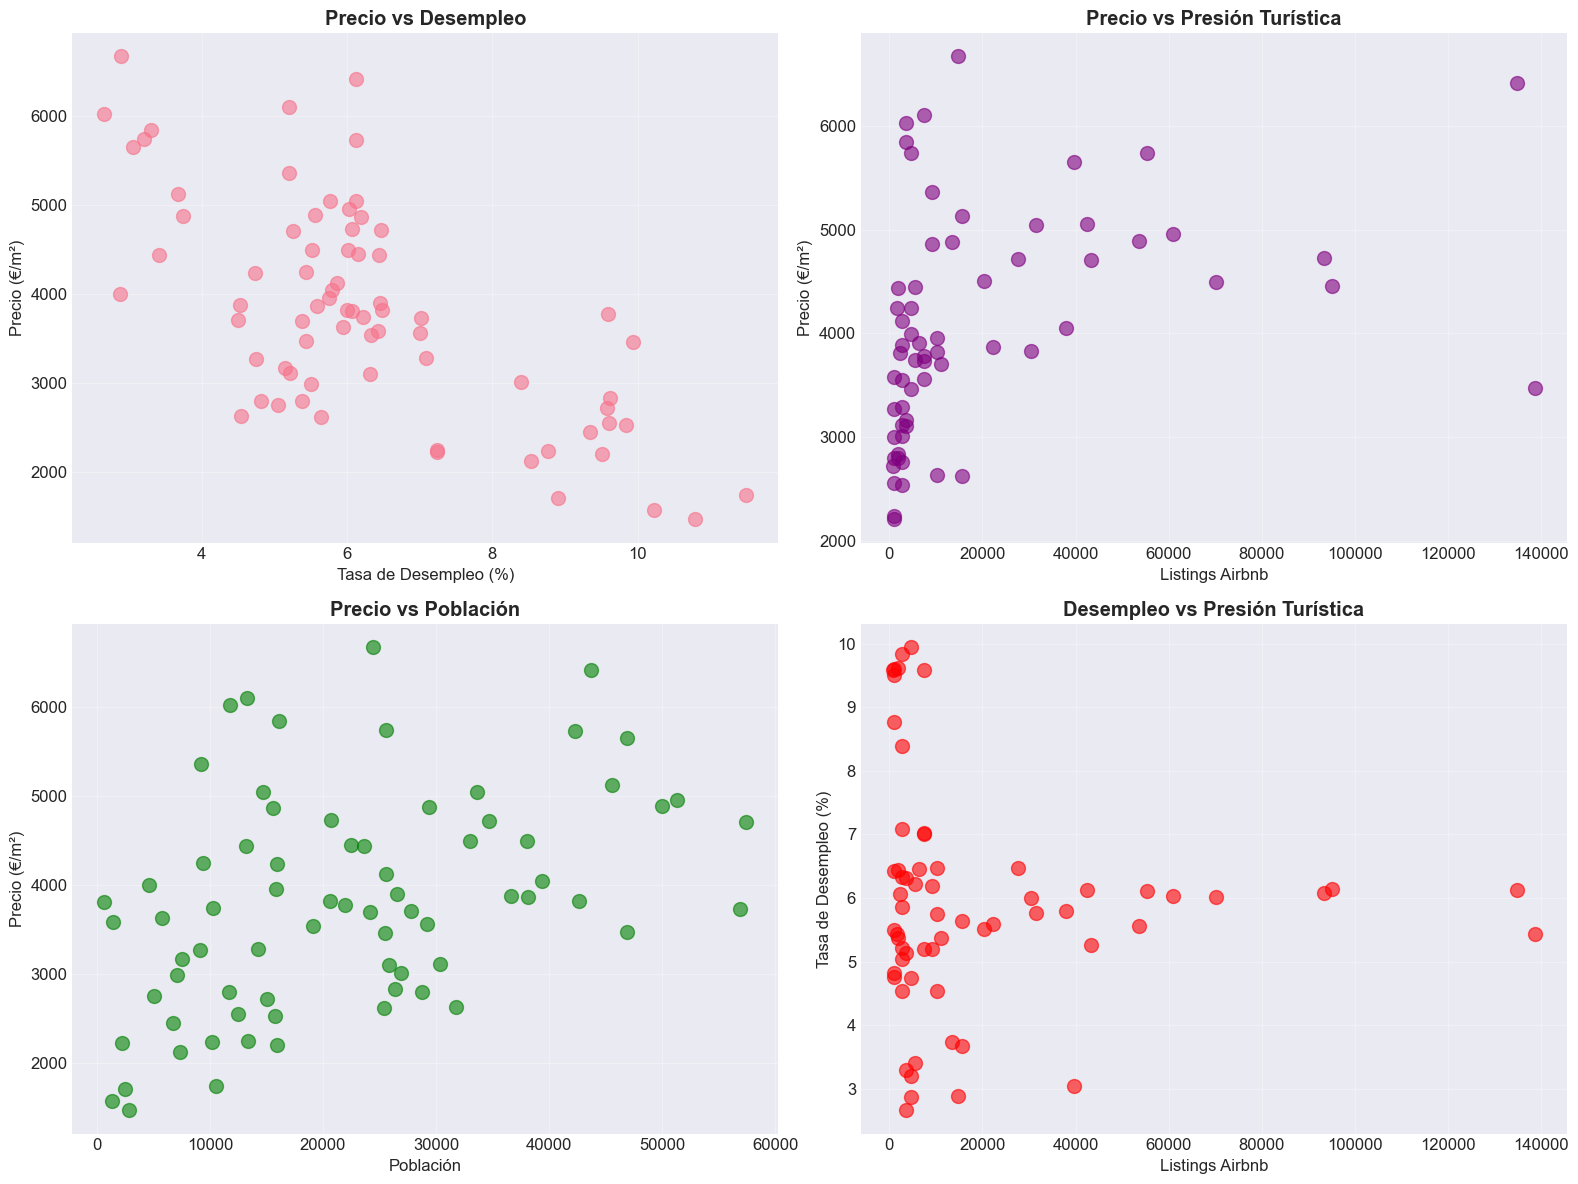

In [20]:
# Scatter plots de correlaciones clave
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Precio vs Desempleo
axes[0, 0].scatter(df_correlaciones['tasa_desempleo'], df_correlaciones['precio_venta'], alpha=0.6, s=100)
axes[0, 0].set_xlabel('Tasa de Desempleo (%)')
axes[0, 0].set_ylabel('Precio (€/m²)')
axes[0, 0].set_title('Precio vs Desempleo', fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Precio vs Airbnb
axes[0, 1].scatter(df_correlaciones['airbnb_listings'], df_correlaciones['precio_venta'], alpha=0.6, s=100, color='purple')
axes[0, 1].set_xlabel('Listings Airbnb')
axes[0, 1].set_ylabel('Precio (€/m²)')
axes[0, 1].set_title('Precio vs Presión Turística', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Precio vs Población
axes[1, 0].scatter(df_correlaciones['poblacion'], df_correlaciones['precio_venta'], alpha=0.6, s=100, color='green')
axes[1, 0].set_xlabel('Población')
axes[1, 0].set_ylabel('Precio (€/m²)')
axes[1, 0].set_title('Precio vs Población', fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Desempleo vs Airbnb
axes[1, 1].scatter(df_correlaciones['airbnb_listings'], df_correlaciones['tasa_desempleo'], alpha=0.6, s=100, color='red')
axes[1, 1].set_xlabel('Listings Airbnb')
axes[1, 1].set_ylabel('Tasa de Desempleo (%)')
axes[1, 1].set_title('Desempleo vs Presión Turística', fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Conclusiones <a id='8-conclusiones'></a>

### Hallazgos Principales

#### 1. Precios de Vivienda
- **Precio medio**: ~3,161€/m² (2024)
- **Rango**: 343€ - 12,154€/m²
- **Tendencia**: Crecimiento sostenido 2012-2025
- **Barrios más caros**: Pedralbes, Sarrià, Tres Torres
- **Barrios más baratos**: Periféricos (Nou Barris, Sant Andreu)

#### 2. Demografía
- **Población total**: ~1.7 millones de habitantes
- **Gran variabilidad**: Barrios de 912 a 60,237 habitantes
- **Distribución**: Relativamente uniforme por distrito

#### 3. Desempleo
- **Tasa media**: 6.27%
- **Rango**: 2.41% - 12.00%
- **Patrón**: Mayor desempleo en barrios periféricos
- **Correlación negativa** con precio de vivienda

#### 4. Presión Turística
- **Distribución altamente sesgada**
- **Concentración**: Ciutat Vella (centro histórico)
- **Crecimiento**: Exponencial 2011-2019, estabilización post-COVID
- **Correlación positiva** con precio de vivienda

### Recomendaciones para Dashboard

1. **Usar escala logarítmica** para variables con distribución sesgada (Airbnb)
2. **Filtros interactivos** por distrito, año, rango de precios
3. **Mapas de calor** para visualización geográfica
4. **Series temporales** para análisis de tendencias
5. **Scatter plots interactivos** para explorar correlaciones

### Próximos Pasos

1. ✅ Datos validados y listos para dashboard
2. ⏳ Implementar dashboard de Streamlit
3. ⏳ Añadir análisis predictivo
4. ⏳ Integrar datos de calidad de aire y ruido

In [21]:
# Cerrar conexión
conn.close()
print("✅ Análisis completado")
print("✅ Conexión cerrada")

✅ Análisis completado
✅ Conexión cerrada
